# Slow and Steady — a quantitative teardown 🔬
### Real total-return tape · 8,168 rolling windows · Wilson CI · overlap-corrected HAC *t* · exposure-vs-timing

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lowers risk?: Confirmed](https://img.shields.io/badge/Lowers_risk%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We separate the two things DCA does — **reduce dispersion** (real) and **beat the lump sum** (it doesn't) — and show the risk reduction is lower exposure, not better timing.

> ⚠️ **Not investment advice.** SPY daily, total-return adjusted (`quantlab.data`, Yahoo); 12 equal monthly tranches; waiting cash earns 0% (conservative-to-DCA). Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (slow_and_steady/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from slow_and_steady import data, strategy

AS_OF = "2026-06-12"
frame = data.load_real("SPY", mode="total_return").loc[:AS_OF]
close = frame["close"]
race = strategy.rolling_race(close, deploy_months=12, step=1)
s = strategy.win_stats(race)
hac_t = strategy.hac_tstat(race["ls_minus_dca"].to_numpy())
print(f"SPY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(f"{s['n_windows']:,} rolling windows | lump-sum wins {s['ls_win_rate']*100:.1f}% | mean gap {s['mean_gap']*100:+.2f} cents/$1 | HAC t {hac_t:+.2f}")
print(f"dispersion: LS std {s['ls_std']:.4f} vs DCA std {s['dca_std']:.4f} (ratio {s['dispersion_ratio']:.3f})")


SPY total return: 8,400 rows  1993-01-29 -> 2026-06-12  fingerprint=eb1569cc9e97
8,168 rolling windows | lump-sum wins 78.6% | mean gap +5.60 cents/$1 | HAC t +16.96
dispersion: LS std 0.1587 vs DCA std 0.0850 (ratio 0.536)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** (DCA beats lump sum?) | `NONE` | Lump-sum wins **78.6%** of **8,168** windows (Wilson CI 77.7-79.5%); mean gap **+5.6 cents/\$1**, HAC *t* = **+17.0** on the overlapping series. DCA loses, decisively. |
| **Tradability** (smarter way?) | `MIRAGE` | The +5.6-cent loss *is* the forgone equity premium on idle cash; the only benefit (lower dispersion) is reproducible more cheaply with a lower stock weight. |
| **Lowers risk?** | `CONFIRMED` | dispersion ratio **0.536** (DCA std 0.085 vs LS 0.159); worst window -37.5% vs -49.3%. |

> 💡 **In plain words:** DCA is a *risk reducer that works* wearing the costume of a *return booster that doesn't*.

## 1 · The claim, steelmanned

- **H₁ (risk):** DCA lowers the dispersion / worst-case of terminal wealth vs a lump sum.
- **H₂ (the sold claim):** DCA beats the lump sum on terminal wealth ("buy at a lower average price").
- **H₃ (mechanism):** if H₁ holds and H₂ fails, the risk reduction is just lower average exposure, not timing skill.

We find H₁ true, H₂ false, and H₃ the explanation — exactly the Vanguard / Constantinides result on a fresh tape.

## 2 · So what? — what rides on each answer

If H₂ held, every all-in investor would be leaving free return behind. It doesn't — and seeing *why* (the opportunity cost of un-deployed cash) is the lesson, and it's the same alpha-vs-beta confusion the desk meets everywhere.

## 3 · How we'd know — the protocol

Rolling-window race over every start date · win-rate with a Wilson interval · HAC *t* on the (heavily overlapping) gap series · dispersion ratio and worst-case for the risk read · exposure decomposition for the mechanism.

## 4 · The teardown

Headline win-rate, with a Wilson interval on the proportion:

In [2]:
p, lo, hi = strategy.wilson_ci(s['ls_wins'], s['n_windows'])
print(f"lump-sum wins {s['ls_wins']:,}/{s['n_windows']:,} = {p*100:.1f}%  "
      f"(Wilson 95% CI {lo*100:.1f}-{hi*100:.1f}%)")
print(f"mean gap {s['mean_gap']*100:+.2f} cents/$1   median gap {s['median_gap']*100:+.2f} cents/$1")

lump-sum wins 6,424/8,168 = 78.6%  (Wilson 95% CI 77.7-79.5%)
mean gap +5.60 cents/$1   median gap +6.22 cents/$1


**HAC inference** on the gap series. The windows overlap by ~a full year, so the gaps are massively autocorrelated and a naive *t* would be absurd — Newey-West with a long lag is the honest read:

In [3]:
g = race['ls_minus_dca'].to_numpy()
naive_t = g.mean() / (g.std(ddof=1) / np.sqrt(len(g)))
hac = strategy.hac_tstat(g)
print(f'mean gap = {g.mean()*100:+.3f} cents/$1')
print(f'naive t (ignores overlap) = {naive_t:+.1f}   <- inflated, do not trust')
print(f'HAC t   (overlap-robust)  = {hac:+.1f}   <- still overwhelmingly positive')

mean gap = +5.600 cents/$1
naive t (ignores overlap) = +55.4   <- inflated, do not trust
HAC t   (overlap-robust)  = +17.0   <- still overwhelmingly positive


> 💡 **In plain words:** even after honestly discounting the fact that neighbouring windows are almost the same window, the lump sum's edge is far too large to be luck.

**Win-rate by deployment horizon** — does drip-feeding *longer* lose by more? (The longer you sit in cash, the more premium you forgo.)

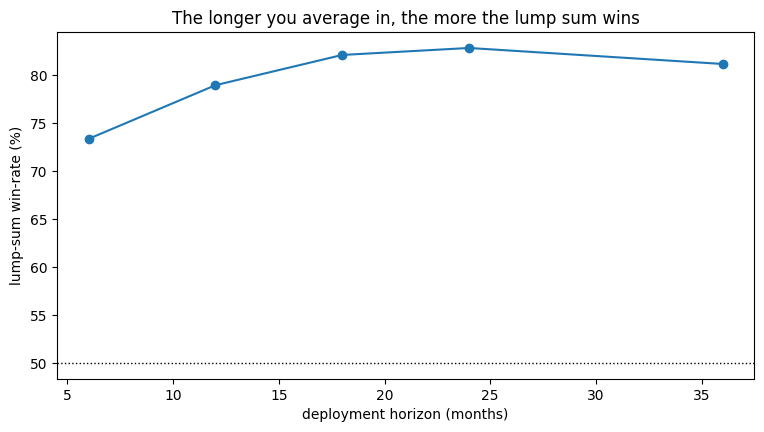

,LS win %,mean gap (cents/$1),disp ratio
deploy_months,,,
6,73.3600,2.4100,0.5400
12,78.9500,5.6200,0.5300
18,82.1000,8.9200,0.5300
24,82.8300,12.6500,0.5200
36,81.1600,20.2200,0.5000


In [4]:
rows = []
for m in [6, 12, 18, 24, 36]:
    rr = strategy.rolling_race(close, deploy_months=m, step=5)
    ss = strategy.win_stats(rr)
    rows.append((m, ss['ls_win_rate']*100, ss['mean_gap']*100, ss['dispersion_ratio']))
hz = pd.DataFrame(rows, columns=['deploy_months','LS win %','mean gap (cents/$1)','disp ratio']).set_index('deploy_months')
fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(hz.index, hz['LS win %'], marker='o')
ax.axhline(50, color='k', ls=':', lw=1)
ax.set_xlabel('deployment horizon (months)'); ax.set_ylabel('lump-sum win-rate (%)')
ax.set_title('The longer you average in, the more the lump sum wins'); plt.show()
hz.round(2)

> 💡 **In plain words:** stretching the drip-feed only makes it worse — more time in cash is more premium left on the table.

**The risk read** — dispersion and worst case, the part that's genuinely DCA's:

In [5]:
print(f"terminal-wealth std : lump-sum {s['ls_std']:.4f}  DCA {s['dca_std']:.4f}  (ratio {s['dispersion_ratio']:.3f})")
print(f"worst window        : lump-sum {s['ls_worst']:.4f}  DCA {s['dca_worst']:.4f}")
print('=> DCA genuinely narrows the spread and cushions the worst case --')
print('   but only by holding ~half its capital out of the market during the year.')

terminal-wealth std : lump-sum 0.1587  DCA 0.0850  (ratio 0.536)
worst window        : lump-sum 0.5068  DCA 0.6250
=> DCA genuinely narrows the spread and cushions the worst case --
   but only by holding ~half its capital out of the market during the year.


> 💡 **In plain words:** the smoother ride is real, but it's *less exposure*, not *better timing* — and you can get less exposure for free by just holding less stock.

## 5 · The verdict

Signal `NONE` (lump-sum wins 78.6%, Wilson 77.7-79.5%, mean gap +5.6 cents/\$1, HAC *t* +17.0); Tradability `MIRAGE` (the gap is the forgone premium); Lowers risk? `CONFIRMED` (dispersion ratio 0.536, worst -37.5% vs -49.3%). DCA's benefit is exposure, not skill.

## 6 · Could you trade it?

Nothing to trade — it's a deployment policy, and the policy loses. The binding fact is economic: DCA holds, on average, only ~half its capital invested during the deployment year, so it forfeits ~half a year of the equity premium — which is precisely the +5.6-cent gap. A risk-averse investor reproduces the lower dispersion with a static lower stock weight and zero cash drag. Constantinides (1979) makes the sub-optimality formal.

## 7 · Going further

- Replace 0% cash with the **T-bill** (`^IRX`) and recompute excess-of-cash for both arms; the gap narrows but does not flip.
- Block-bootstrap the **win-rate** (not just the gap) for a CI that respects the overlap beyond Wilson's i.i.d. assumption.
- Cross-asset: on a fat-left-tail asset (EM, credit) does DCA's worst-case cushion become worth its return cost?